В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.



Посилання на файл: https://github.com/Kateryna-Korniichuk/ml_home_tasks/blob/main/process_bank_churn.py

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!git clone https://github.com/Kateryna-Korniichuk/ml_home_tasks.git
%cd ml_home_tasks
!ls

Cloning into 'ml_home_tasks'...
remote: Enumerating objects: 84, done.
remote: Counting objects: 100% (84/84), done.
remote: Compressing objects: 100% (82/82), done.
remote: Total 84 (delta 31), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (84/84), 4.15 MiB | 9.63 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/ml_home_tasks
 HW_1_1_Основи_статистики.ipynb
 HW_1_2_Credit_EDA.ipynb
 HW1_Змінні_та_основні_типи_даних_в_Python.ipynb
 HW_2_1_Лінійна_регресія_від_багатьох_змінних.ipynb
'HW_2_1_Матриці_і_вектори_(вступ_до_лін_алгебри).ipynb'
 HW_2_1_Побудова_лінійної_регресії_за_одною_ознакою.ipynb
 HW_2_1_Тестування_стат_гіпотез.ipynb
 HW_2_1_Функції_і_похідні.ipynb
 HW_2_2_Логістична_регресія_з_scikit_learn.ipynb
 HW_2_2_Математичне_формулювання_логістичної_регресії.ipynb
 HW_2_2_Незбалансована_багатокласова_класифікація.ipynb
 HW_2_2_Поліноміальні_ознаки_Pipelines.ipynb
 HW2_Списки_та_словники.ipynb
'HW3_Умовні_конструкції_(if_elif_else).ipynb'
 HW

In [3]:
from process_bank_churn import preprocess_data, preprocess_new_data

In [4]:
import pandas as pd

raw_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/train.csv')

X_train, y_train, X_val, y_val, input_cols, scaler, encoder = preprocess_data(
    raw_df,
    scale_numeric_flag=True
)

print(X_train.shape, X_val.shape)

(12000, 11) (3000, 11)


**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

In [5]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(random_state=42)

In [6]:
%%time
model.fit(X_train, y_train)

CPU times: user 95.2 ms, sys: 0 ns, total: 95.2 ms
Wall time: 99.8 ms


DecisionTreeClassifier(random_state=42)

In [7]:
from sklearn.metrics import roc_auc_score

print("area under ROC train:", roc_auc_score(y_train, model.predict_proba(X_train)[:,1]))
print("area under ROC validation:", roc_auc_score(y_val, model.predict_proba(X_val)[:,1]))

area under ROC train: 1.0
area under ROC validation: 0.7733349338089032


**Висновки**

area under ROC на train 1.0, а на validation 0.773. Модель перенавчилась, ідеально запамятала вхідні дані і погано генералізує

In [8]:
model.tree_.max_depth

25

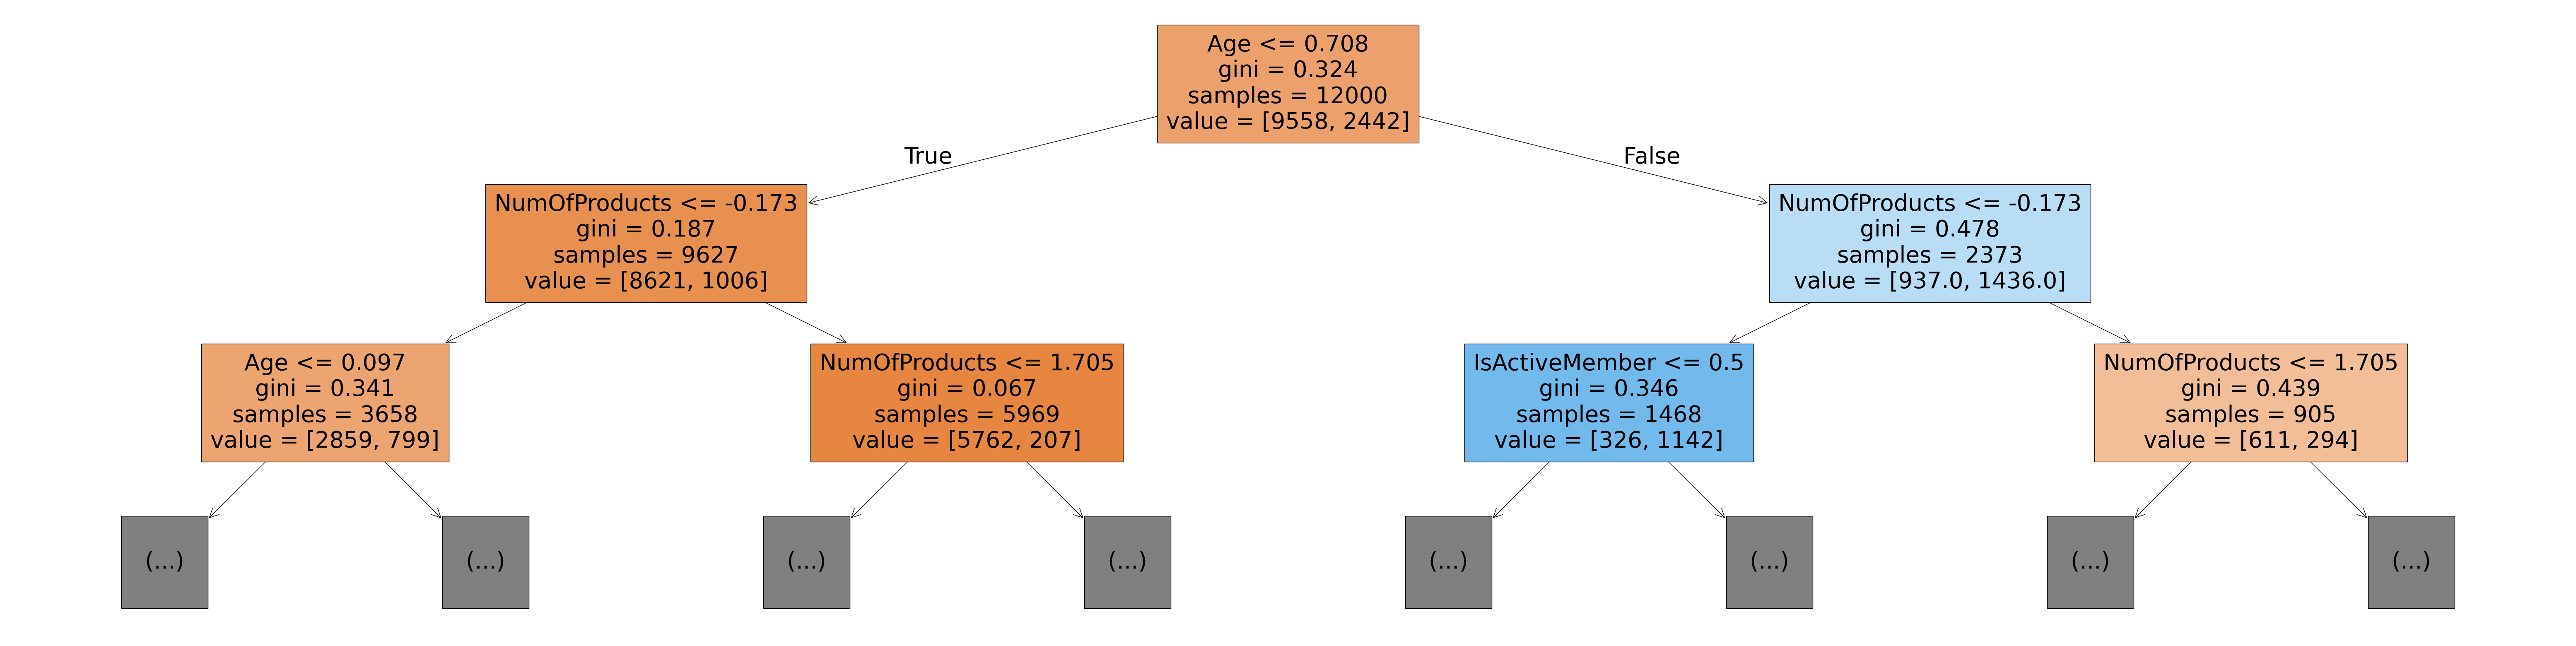

In [9]:
from sklearn.tree import plot_tree, export_text
import matplotlib.pyplot as plt

plt.figure(figsize=(80,20))
plot_tree(model, feature_names=X_train.columns, max_depth=2, filled=True);

**Висновки**

найвпливовіші ознаки: Age, NumOfProducts, IsActiveMember

In [10]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

In [11]:
importance_df.head(10)

,feature,importance
1,Age,0.346515
4,NumOfProducts,0.166648
7,EstimatedSalary,0.138141
0,CreditScore,0.119031
3,Balance,0.083713
2,Tenure,0.045241
6,IsActiveMember,0.039304
10,Gender_Male,0.018660
8,Geography_Germany,0.018236
5,HasCrCard,0.013030


**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

In [12]:
model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)

print("area under ROC train:", roc_auc_score(y_train, model.predict_proba(X_train)[:,1]))
print("area under ROC validation:", roc_auc_score(y_val, model.predict_proba(X_val)[:,1]))

area under ROC train: 0.9245929074083499
area under ROC validation: 0.9224175183483092


In [13]:
model = DecisionTreeClassifier(max_leaf_nodes=37, random_state=42).fit(X_train, y_train)
print("area under ROC train:", roc_auc_score(y_train, model.predict_proba(X_train)[:,1]))
print("area under ROC validation:", roc_auc_score(y_val, model.predict_proba(X_val)[:,1]))

area under ROC train: 0.9287085836050055
area under ROC validation: 0.9243449482131834


**Висновки**

Трохи поекспериментувала з параметрами max_depth та max_leaf_nodes, обмеження складності моделі значно зменшило перенавчання у порівнянні з моделлю за замовченням. Найкращий результат на валідаційній вибірці показала модель з max_leaf_nodes=37, ROC-AUC = 0.924, різниця між train і validation мінімальна

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

In [14]:
def max_depth_auroc(md):
    model = DecisionTreeClassifier(max_depth=md, random_state=42)
    model.fit(X_train, y_train)
    auroc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:,1])
    auroc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:,1])
    return {'Max Depth': md, 'auroc Train': auroc_train, 'auroc Val': auroc_val}

In [15]:
%%time
auroc_df = pd.DataFrame([max_depth_auroc(md) for md in range(1, 21)])

CPU times: user 1.31 s, sys: 7.68 ms, total: 1.31 s
Wall time: 1.36 s


In [16]:
auroc_df

,Max Depth,auroc Train,auroc Val
0,1,0.745005,0.733747
1,2,0.843844,0.843126
2,3,0.898620,0.893736
3,4,0.911807,0.907608
4,5,0.924593,0.922418
5,6,0.933503,0.921315
6,7,0.940658,0.914438
7,8,0.949093,0.902551
8,9,0.959592,0.880441
9,10,0.968901,0.868820


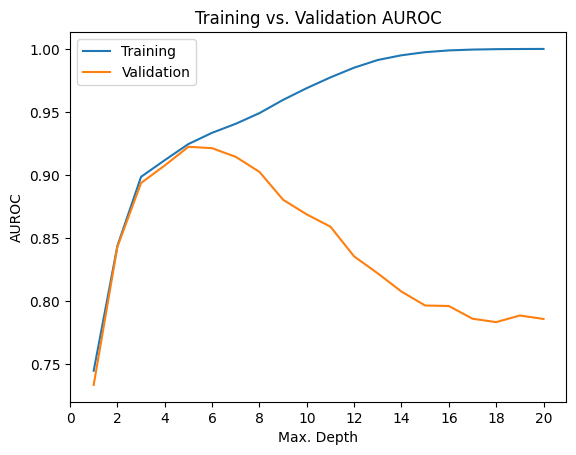

In [17]:
plt.figure()
plt.plot(auroc_df['Max Depth'], auroc_df['auroc Train'])
plt.plot(auroc_df['Max Depth'], auroc_df['auroc Val'])
plt.title('Training vs. Validation AUROC')
plt.xticks(range(0,21, 2))
plt.xlabel('Max. Depth')
plt.ylabel('AUROC')
plt.legend(['Training', 'Validation']);

**Висновки**

при глибині 1-2 модель занадто проста, 3-6 оптимально, після 7 - оверфіттінг. Найкраща глибина 5

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)


In [18]:
model = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_train, y_train)


In [19]:
test_raw = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/test.csv')
test_ids = test_raw['id'].copy()

X_test = preprocess_new_data(
    test_raw,
    input_cols=input_cols,
    encoder=encoder,
    scaler=scaler,
    scale_numeric_flag=True
)

X_test.head(5)

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
0,-1.035836,-0.941500,-1.090989,1.732261,-1.111777,1.0,1.0,0.878609,1.0,0.0,1.0
1,-1.490729,0.158288,-0.008838,-0.716938,0.766225,1.0,1.0,-1.088535,0.0,0.0,1.0
2,0.645888,0.647083,1.073314,-0.716938,0.766225,1.0,0.0,0.854179,0.0,0.0,1.0
3,0.797519,0.891480,-0.730272,-0.716938,-1.111777,1.0,1.0,1.074713,0.0,1.0,1.0
4,-0.925559,0.647083,1.073314,-0.716938,0.766225,1.0,1.0,0.569602,0.0,1.0,1.0


In [20]:
test_pred = model.predict_proba(X_test)[:,1]
test_pred

array([0.18039216, 0.03108808, 0.03108808, ..., 0.00940594, 0.04109589,
       0.18429662])

In [21]:
submission = pd.DataFrame({
    'id': test_ids,
    'Exited': test_pred
})

submission

,id,Exited
0,15000,0.180392
1,15001,0.031088
2,15002,0.031088
3,15003,0.738532
4,15004,0.031088
...,...,...
9995,24995,0.009406
9996,24996,0.031088
9997,24997,0.009406
9998,24998,0.041096


In [22]:
submission.to_csv('submission.csv', index=False)

In [23]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

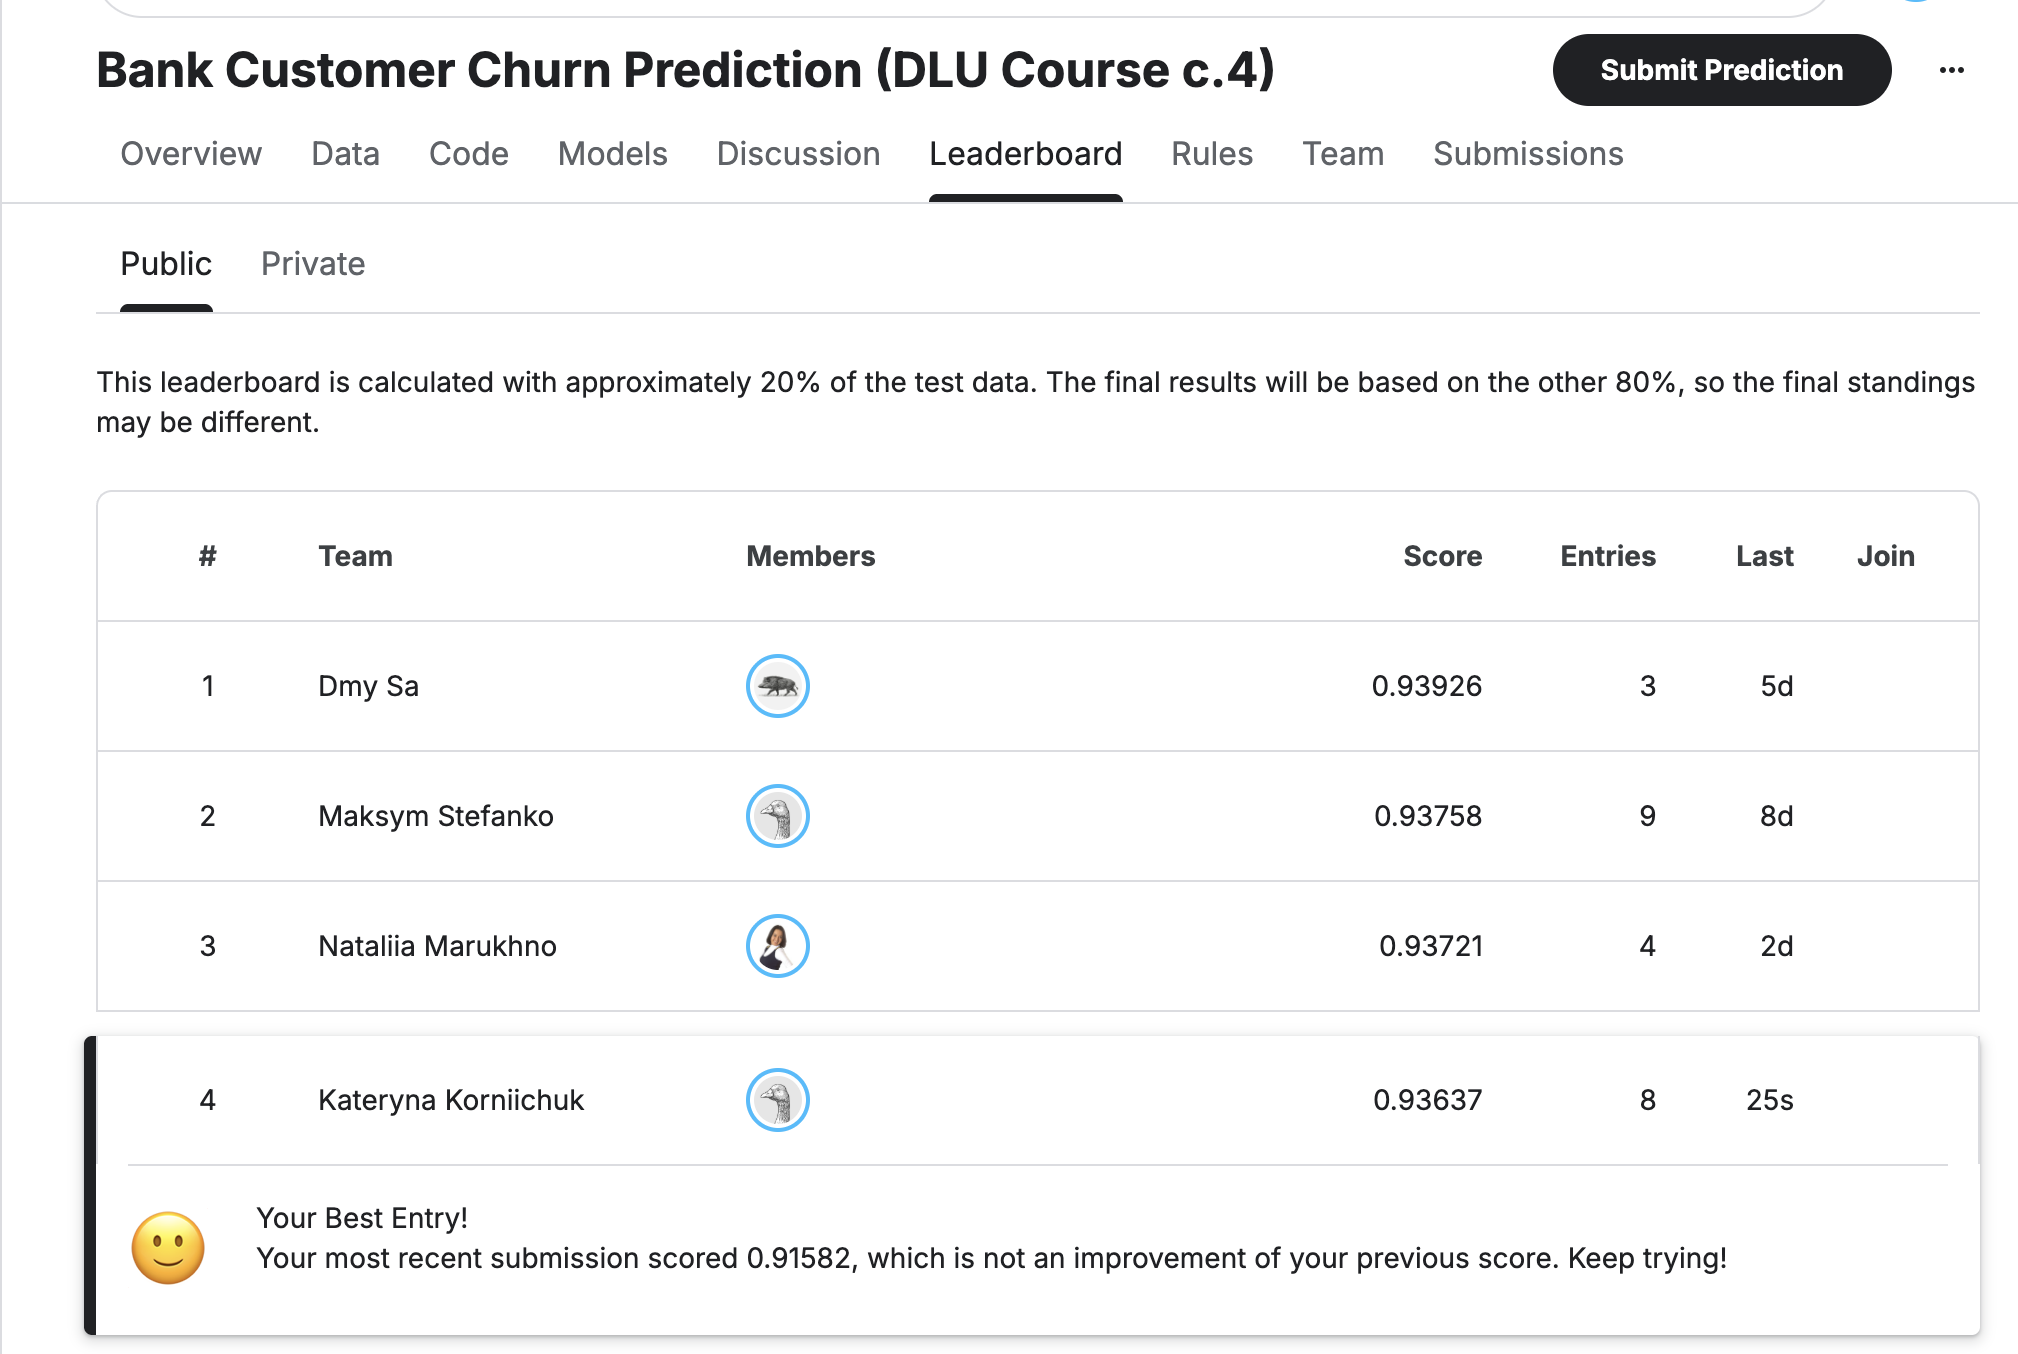

In [26]:
from IPython.display import Image, display

display(Image(filename='/content/Kaggle_score.png'))

**Висновки**

Це не була моя найкраща спроба, наступним кроком спробую натренувати дерево з моїми фічами)